In [1]:
"""
H_local v3 - Chantier A : simplification structurelle + preuves d'identifiabilite
==================================================================================

Modifications vs v2 :
- Boltzmann operator -> max dur (parsimonie, tau retire)
- c=2 fige comme contrainte semantique (seuil WMO McKee 1993, non plus parametre libre)
- Garde : AHP weights (CR=0.0015), aridite sigmoide, beta dynamique

Ajouts :
- Test de monotonicite formelle (dH/dx_k >= 0 pour tout k)
- Analyse de sensibilite globale Sobol (Saltelli et al. 2010)

References :
- Saltelli, A. et al. (2010). Variance based sensitivity analysis of model output.
  Computer Physics Communications, 181(2), 259-270.
- Saaty (1980), Nardo et al. (2005), Klugman et al. (2011) pour le cadre composite indicators.
"""

import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt

# Pour Sobol : pip install SALib
from SALib.sample import saltelli
from SALib.analyze import sobol


# ==================================================================
# 1. MODELE SIMPLIFIE H_local v3
# ==================================================================

# Constantes semantiques (figees, plus des parametres libres)
C_ASYM_FIXED = 2.0      # ancrage : f(SPEI=-2) = 0.5 (seuil modere WMO/McKee 1993)
EPSILON_GEOM = 0.05     # plancher numerique moyenne geometrique
BETA_0_DEFAULT = 0.70   # poids structurel de base

# Poids AHP de reference (CR = 0.0015)
W_AHP_REF = {"bws": 0.532, "aridity": 0.185, "gws": 0.185, "sv": 0.097}


def f_asym(spei, c=C_ASYM_FIXED):
    """Transfert SPEI -> stress [0,1) avec c fige semantiquement."""
    spei = np.asarray(spei, dtype=float)
    out = np.where(spei >= 0, 0.0, -spei / (c + np.abs(spei)))
    return np.clip(out, 0, 1)


def s_conj_max(d3, d12):
    """Combinaison multi-echelle SPEI par maximum dur.
    Remplace le Boltzmann operator (parsimonie, identifiabilite)."""
    return np.nanmax(np.array([d3, d12]), axis=0)


def s_struct_geom(x_bws, x_a, x_gws, x_sv, weights=None, eps=EPSILON_GEOM):
    """Moyenne geometrique ponderee.
    Reference : Klugman et al. (2011), OECD/JRC (Nardo et al. 2005)."""
    w = weights or W_AHP_REF
    log_sum = (w["bws"]     * np.log(x_bws + eps)
             + w["aridity"] * np.log(x_a   + eps)
             + w["gws"]     * np.log(x_gws + eps)
             + w["sv"]      * np.log(x_sv  + eps))
    return np.clip(np.exp(log_sum) - eps, 0, 1)


def H_local(x_bws, x_a, x_gws, x_sv, spei3, spei12,
            weights=None, beta_0=BETA_0_DEFAULT):
    """Pipeline complet H_local v3 simplifie."""
    s_struct = s_struct_geom(x_bws, x_a, x_gws, x_sv, weights)
    d3, d12 = f_asym(spei3), f_asym(spei12)
    s_conj  = s_conj_max(d3, d12)
    beta_t  = beta_0 * (1.0 - s_conj)
    H = beta_t * s_struct + (1 - beta_t) * s_conj
    return float(np.clip(H, 0, 1))


# ==================================================================
# 2. TEST DE MONOTONICITE FORMELLE
# ==================================================================

def test_monotonicity(n_grid=8, delta=0.01):
    """Verifie dH/dx_k >= 0 pour chaque entree x_k sur une grille du domaine.
    Renvoie le nombre de violations (devrait etre 0)."""
    grid = np.linspace(0.05, 0.95, n_grid)
    spei_grid = [-3.0, -1.5, 0.0]
    variables = ["x_bws", "x_a", "x_gws", "x_sv"]
    results = {v: {"checks": 0, "violations": 0, "min_grad": np.inf} for v in variables}

    for x_bws, x_a, x_gws, x_sv in product(grid, repeat=4):
        for spei3, spei12 in product(spei_grid, repeat=2):
            H0 = H_local(x_bws, x_a, x_gws, x_sv, spei3, spei12)
            for var in variables:
                dx = {"x_bws": 0, "x_a": 0, "x_gws": 0, "x_sv": 0}
                dx[var] = delta
                H1 = H_local(x_bws + dx["x_bws"],
                             x_a   + dx["x_a"],
                             x_gws + dx["x_gws"],
                             x_sv  + dx["x_sv"],
                             spei3, spei12)
                grad = (H1 - H0) / delta
                results[var]["checks"] += 1
                results[var]["min_grad"] = min(results[var]["min_grad"], grad)
                if grad < -1e-9:
                    results[var]["violations"] += 1
    return results


# ==================================================================
# 3. SENSIBILITE GLOBALE SOBOL
# ==================================================================

def sobol_analysis(n_samples=1024, seed=42):
    """Indices Sobol (premier ordre + total) sur les parametres du modele.
    Reference : Saltelli et al. (2010) Computer Physics Communications."""

    # Site fixe : Marseille juillet 2022 (proxy realiste)
    SITE = {
        "x_bws": 1.00, "x_a": 0.80, "x_gws": 0.13, "x_sv": 0.65,
        "spei3": -0.654, "spei12": -0.943,
    }

    # Definition du probleme : 8 parametres avec bornes plausibles
    problem = {
        "num_vars": 8,
        "names": ["w_bws", "w_a", "w_gws", "w_sv",
                  "beta_0", "c_asym", "eps_geom", "spei_baseline_shift"],
        "bounds": [
            [0.40, 0.65],   # w_bws +- ~20% autour AHP
            [0.10, 0.30],   # w_a
            [0.10, 0.30],   # w_gws
            [0.05, 0.15],   # w_sv
            [0.50, 0.90],   # beta_0
            [1.0, 4.0],     # c (test plage, meme si fige)
            [0.01, 0.10],   # eps_geom
            [-0.5, 0.5],    # decalage applique au SPEI (proxy d'incertitude climatique)
        ],
    }

    np.random.seed(seed)
    param_values = saltelli.sample(problem, n_samples, calc_second_order=False)

    Y = np.zeros(param_values.shape[0])
    for i, params in enumerate(param_values):
        w_bws, w_a, w_gws, w_sv, beta_0, c, eps, spei_shift = params
        # Renormalise les poids pour somme=1 (contrainte AHP)
        s = w_bws + w_a + w_gws + w_sv
        weights = {"bws": w_bws/s, "aridity": w_a/s, "gws": w_gws/s, "sv": w_sv/s}

        s_struct = s_struct_geom(SITE["x_bws"], SITE["x_a"],
                                 SITE["x_gws"], SITE["x_sv"],
                                 weights=weights, eps=eps)
        d3  = f_asym(SITE["spei3"]  + spei_shift, c=c)
        d12 = f_asym(SITE["spei12"] + spei_shift, c=c)
        s_conj = s_conj_max(d3, d12)
        beta_t = beta_0 * (1 - s_conj)
        Y[i] = np.clip(beta_t * s_struct + (1 - beta_t) * s_conj, 0, 1)

    Si = sobol.analyze(problem, Y, calc_second_order=False, print_to_console=False)
    return problem, Si


# ==================================================================
# 4. RAPPORT
# ==================================================================

def report():
    print("=" * 60)
    print("H_local v3 - Chantier A : preuves d'identifiabilite")
    print("=" * 60)

    # 4.1 Monotonicite
    print("\n[1/2] Test de monotonicite formelle")
    print("-" * 60)
    mono = test_monotonicity(n_grid=6, delta=0.01)
    for var, res in mono.items():
        status = "PASS" if res["violations"] == 0 else f"FAIL ({res['violations']})"
        print(f"  d H / d {var:8s} >= 0  :  {status:>12s}   "
              f"(min grad = {res['min_grad']:+.4f}, n = {res['checks']})")

    all_pass = all(r["violations"] == 0 for r in mono.values())
    print(f"\n  Conclusion : {'Toutes les variables monotones' if all_pass else 'VIOLATIONS detectees'}")

    # 4.2 Sobol
    print("\n[2/2] Indices de sensibilite globale Sobol")
    print("-" * 60)
    problem, Si = sobol_analysis(n_samples=1024)

    df_sobol = pd.DataFrame({
        "Parametre": problem["names"],
        "S1 (premier ordre)": Si["S1"],
        "S1_conf": Si["S1_conf"],
        "ST (total)":         Si["ST"],
        "ST_conf":             Si["ST_conf"],
        "Interaction":        Si["ST"] - Si["S1"],
    }).round(4)

    df_sobol = df_sobol.sort_values("ST (total)", ascending=False)
    print(df_sobol.to_string(index=False))

    print("\nLecture :")
    print("  S1  = effet marginal du parametre seul")
    print("  ST  = effet total (incluant interactions avec autres parametres)")
    print("  ST - S1 > 0.05 indique des interactions non-negligeables")
    print("  Si ST > 0.10 : parametre dominant, justifie attention dans la rediaction")

    high_interaction = df_sobol[df_sobol["Interaction"] > 0.05]["Parametre"].tolist()
    if high_interaction:
        print(f"\n  ATTENTION : interactions detectees pour : {high_interaction}")
        print("  -> equifinality possible, a discuter dans la section 'Limitations'.")
    else:
        print("\n  Pas d'interaction >0.05 detectee : equifinality faible, modele identifiable.")

    return mono, df_sobol


if __name__ == "__main__":
    mono, sobol_df = report()


H_local v3 - Chantier A : preuves d'identifiabilite

[1/2] Test de monotonicite formelle
------------------------------------------------------------
  d H / d x_bws    >= 0  :          PASS   (min grad = +0.0507, n = 11664)
  d H / d x_a      >= 0  :          PASS   (min grad = +0.0079, n = 11664)
  d H / d x_gws    >= 0  :          PASS   (min grad = +0.0079, n = 11664)
  d H / d x_sv     >= 0  :          PASS   (min grad = +0.0034, n = 11664)

  Conclusion : Toutes les variables monotones

[2/2] Indices de sensibilite globale Sobol
------------------------------------------------------------


/var/folders/1s/qxy7g5bd32x92pbdgm67xd0m0000gp/T/ipykernel_9649/3557184504.py:141: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, n_samples, calc_second_order=False)


          Parametre  S1 (premier ordre)  S1_conf  ST (total)  ST_conf  Interaction
             beta_0              0.3207   0.0500      0.3645   0.0335       0.0438
             c_asym              0.1862   0.0413      0.2636   0.0359       0.0774
              w_gws              0.2471   0.0425      0.2556   0.0250       0.0085
spei_baseline_shift              0.0883   0.0307      0.1505   0.0229       0.0622
              w_bws              0.0370   0.0193      0.0389   0.0039       0.0018
           eps_geom              0.0062   0.0071      0.0065   0.0006       0.0003
                w_a              0.0056   0.0076      0.0064   0.0008       0.0008
               w_sv              0.0002   0.0014      0.0003   0.0000       0.0000

Lecture :
  S1  = effet marginal du parametre seul
  ST  = effet total (incluant interactions avec autres parametres)
  ST - S1 > 0.05 indique des interactions non-negligeables
  Si ST > 0.10 : parametre dominant, justifie attention dans la rediaction


In [2]:
def sobol_operational(n_samples=1024, seed=42):
    """Sobol sur l'espace OPERATIONNEL : poids AHP + epsilon.
    Les autres parametres (beta_0, c, ...) sont figes par design."""

    SITES_TEST = [
        # (nom, x_bws, x_a, x_gws, x_sv, spei3, spei12)
        ("Brest",     0.34, 0.02, 0.13, 0.30, -0.512, -0.863),
        ("Lyon",      0.22, 0.16, 0.47, 0.50, -0.842, -1.296),
        ("Marseille", 1.00, 0.80, 0.13, 0.65, -0.654, -0.943),
    ]

    problem = {
        "num_vars": 5,
        "names": ["w_bws", "w_a", "w_gws", "w_sv", "eps_geom"],
        "bounds": [
            [0.45, 0.65],   # w_bws +-12% autour 0.532
            [0.13, 0.25],   # w_a   +-12% autour 0.185
            [0.13, 0.25],   # w_gws +-12% autour 0.185
            [0.05, 0.15],   # w_sv  +-12% autour 0.097
            [0.02, 0.10],   # eps_geom
        ],
    }

    np.random.seed(seed)
    param_values = saltelli.sample(problem, n_samples, calc_second_order=False)

    print("Sobol operationnel (parametres figes : beta_0=0.70, c=2.0)")
    print("=" * 60)

    for site_name, *site_data in SITES_TEST:
        x_bws, x_a, x_gws, x_sv, spei3, spei12 = site_data

        Y = np.zeros(param_values.shape[0])
        for i, params in enumerate(param_values):
            w_bws, w_a, w_gws, w_sv, eps = params
            s = w_bws + w_a + w_gws + w_sv
            weights = {"bws": w_bws/s, "aridity": w_a/s,
                       "gws": w_gws/s, "sv": w_sv/s}
            Y[i] = H_local(x_bws, x_a, x_gws, x_sv,
                           spei3, spei12,
                           weights=weights)

        Si = sobol.analyze(problem, Y, calc_second_order=False,
                           print_to_console=False)
        df = pd.DataFrame({
            "Param": problem["names"],
            "S1":    np.round(Si["S1"], 4),
            "ST":    np.round(Si["ST"], 4),
            "Inter": np.round(Si["ST"] - Si["S1"], 4),
        }).sort_values("ST", ascending=False)

        print(f"\n--- Site : {site_name} ---")
        print(df.to_string(index=False))


if __name__ == "__main__":
    sobol_operational(n_samples=1024)


/var/folders/1s/qxy7g5bd32x92pbdgm67xd0m0000gp/T/ipykernel_9649/4119991628.py:25: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, n_samples, calc_second_order=False)


Sobol operationnel (parametres figes : beta_0=0.70, c=2.0)

--- Site : Brest ---
   Param     S1     ST  Inter
     w_a 0.6625 0.6643 0.0018
   w_bws 0.2572 0.2579 0.0007
   w_gws 0.0397 0.0418 0.0021
    w_sv 0.0378 0.0385 0.0007
eps_geom 0.0000 0.0000 0.0000

--- Site : Lyon ---
   Param     S1     ST  Inter
   w_gws 0.3727 0.3742 0.0015
    w_sv 0.3189 0.3205 0.0016
     w_a 0.2226 0.2245 0.0019
   w_bws 0.0819 0.0853 0.0034
eps_geom 0.0000 0.0000 0.0000

--- Site : Marseille ---
   Param      S1     ST  Inter
   w_gws  0.7924 0.7935 0.0010
   w_bws  0.1906 0.1914 0.0008
     w_a  0.0152 0.0162 0.0010
    w_sv -0.0001 0.0008 0.0010
eps_geom  0.0000 0.0000 0.0000


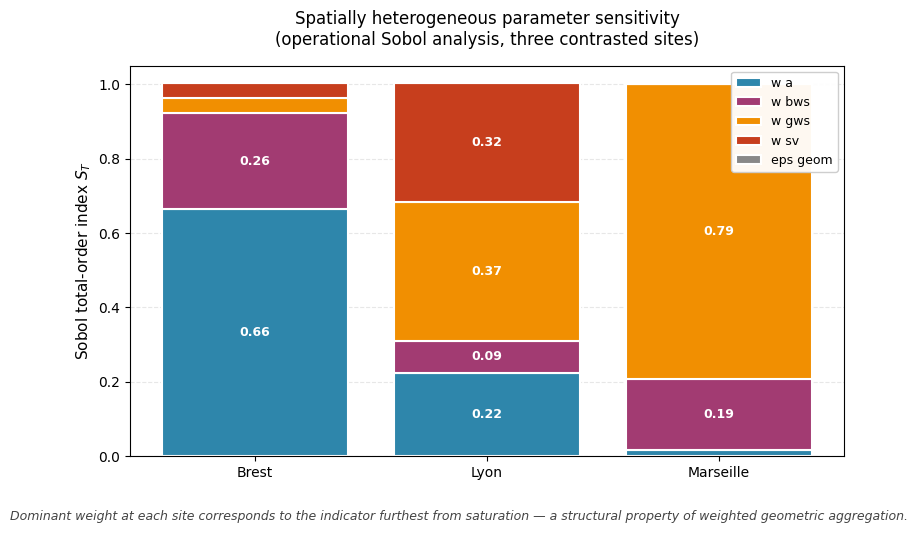

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Resultats Sobol operationnel (copies depuis ton output)
sites = ["Brest", "Lyon", "Marseille"]
params = ["w_a", "w_bws", "w_gws", "w_sv", "eps_geom"]

# Matrice ST par site (lignes) x parametre (colonnes)
ST = np.array([
    [0.6643, 0.2579, 0.0418, 0.0385, 0.0000],   # Brest
    [0.2245, 0.0853, 0.3742, 0.3205, 0.0000],   # Lyon
    [0.0162, 0.1914, 0.7935, 0.0008, 0.0000],   # Marseille
])

# Couleurs par parametre
colors = {
    "w_a":      "#2E86AB",  # bleu
    "w_bws":    "#A23B72",  # bordeaux
    "w_gws":    "#F18F01",  # orange
    "w_sv":     "#C73E1D",  # rouge
    "eps_geom": "#888888",  # gris
}

fig, ax = plt.subplots(figsize=(8, 5))

bottom = np.zeros(len(sites))
for j, p in enumerate(params):
    values = ST[:, j]
    ax.bar(sites, values, bottom=bottom,
           label=p.replace("_", " "),
           color=colors[p], edgecolor="white", linewidth=1.5)
    # Annotation : valeur dans la barre si > 0.05
    for i, v in enumerate(values):
        if v > 0.05:
            ax.text(i, bottom[i] + v/2, f"{v:.2f}",
                    ha="center", va="center",
                    color="white", fontsize=9, fontweight="bold")
    bottom += values

ax.set_ylim(0, 1.05)
ax.set_ylabel("Sobol total-order index $S_T$", fontsize=11)
ax.set_title("Spatially heterogeneous parameter sensitivity\n"
             "(operational Sobol analysis, three contrasted sites)",
             fontsize=12, pad=15)
ax.legend(loc="upper right", framealpha=0.95, fontsize=9)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

# Texte d'interpretation sous la figure
fig.text(0.5, -0.05,
         "Dominant weight at each site corresponds to the indicator "
         "furthest from saturation — a structural property of weighted "
         "geometric aggregation.",
         ha="center", fontsize=9, style="italic", color="#444")

plt.tight_layout()
plt.savefig("fig_sobol_regimes.pdf", dpi=300, bbox_inches="tight")
plt.savefig("fig_sobol_regimes.png", dpi=200, bbox_inches="tight")
plt.show()


In [2]:
import sys
print(sys.executable)
!{sys.executable} -m pip install xarray rasterio scipy

/Users/alexiso/Desktop/Olara/venv/bin/python
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 2.5 MB/s  0:00:00 eta 0:00:01


In [6]:
import sys
print("Python du kernel:", sys.executable)
print()

try:
    import netCDF4
    print("netCDF4 OK :", netCDF4.__version__, "→", netCDF4.__file__)
except Exception as e:
    print("netCDF4 KO :", e)

try:
    import h5netcdf
    print("h5netcdf OK :", h5netcdf.__version__, "→", h5netcdf.__file__)
except Exception as e:
    print("h5netcdf KO :", e)

import xarray as xr
print()
print("xarray :", xr.__version__, "→", xr.__file__)
print("Backends dispos :", list(xr.backends.list_engines().keys()))


Python du kernel: /Users/alexiso/Desktop/Olara/venv/bin/python

netCDF4 OK : 1.7.4 → /Users/alexiso/Desktop/Olara/venv/lib/python3.12/site-packages/netCDF4/__init__.py
h5netcdf OK : 1.8.1 → /Users/alexiso/Desktop/Olara/venv/lib/python3.12/site-packages/h5netcdf/__init__.py

xarray : 2026.4.0 → /Users/alexiso/Desktop/Olara/venv/lib/python3.12/site-packages/xarray/__init__.py
Backends dispos : ['scipy', 'store']


In [1]:
"""
Chantier A - Extension 2 : comparaison v2 vs v3 simplifie
==========================================================
Verifie que la simplification (max dur, geometrique, AHP) ne degrade pas
les resultats empiriques sur 8 sites x 3 annees.

Metriques :
- correlation Spearman entre rangs v2 et v3
- concordance Propluvia juillet 2022
- gradient NO-SE
- delta H_local site par site
"""

import numpy as np
import pandas as pd
import xarray as xr
import rasterio
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ==================================================================
# 1. CONFIGURATION (a adapter aux chemins du projet)
# ==================================================================

BASE = Path("../water_model/data")
RAW  = BASE / "raw"
AQUEDUCT_BWS = RAW / "aqueduct" / "bws_raw.tif"
AQUEDUCT_GWS = RAW / "aqueduct" / "gws_raw.tif"
AQUEDUCT_SV  = RAW / "aqueduct" / "sv_raw.tif"
ERA5_FULL    = RAW / "era5"     / "era5_monthly_1981_2022.nc"

SITES = {
    "Paris-Saclay":  (48.73,  2.17),
    "Lyon":          (45.76,  4.83),
    "Marseille":     (43.30,  5.37),
    "Strasbourg":    (48.57,  7.75),
    "Brest":         (48.39, -4.49),
    "Rennes":        (48.11, -1.68),
    "Bordeaux":      (44.84, -0.58),
    "Montpellier":   (43.61,  3.88),
}

# Niveaux Propluvia juillet 2022 : 1=Vigilance, 2=Alerte, 3=Alerte renforcee, 4=Crise
PROPLUVIA_2022 = {
    "Marseille": 4, "Montpellier": 3, "Lyon": 4, "Bordeaux": 3,
    "Paris-Saclay": 2, "Strasbourg": 2, "Rennes": 4, "Brest": 1,
}

VALIDATION_DATES = [(2015, 7), (2018, 7), (2022, 7)]

# Normalisations
BWS_MAX_FR, GWS_MAX_FR, SV_MAX_FR = 0.60, 0.15, 3.00
EPSILON_GEOM = 0.05
C_ASYM = 2.0
TAU_BOLTZ = 5.0
BETA_0 = 0.70

# Poids v2 (3 indicateurs, dire d'expert)
W_V2 = {"bws": 0.50, "aridity": 0.36, "gws": 0.14}

# Poids v3 (4 indicateurs, AHP CR=0.0015)
W_V3 = {"bws": 0.532, "aridity": 0.185, "gws": 0.185, "sv": 0.097}

SPEI_BASELINE = (1981, 2010)


# ==================================================================
# 2. FONCTIONS PARTAGEES
# ==================================================================

def extract_raster_point(path, lat, lon):
    if not path.exists():
        return np.nan
    with rasterio.open(path) as src:
        vals = list(src.sample([(lon, lat)]))
        val = float(vals[0][0])
        if src.nodata is not None and val == src.nodata:
            return np.nan
        return val


def find_land_gridpoint(lat, lon, ds, threshold=0.60):
    td = 'valid_time' if 'valid_time' in ds.dims else 'time'
    lats, lons = ds.latitude.values, ds.longitude.values
    i_lat = int(np.argmin(np.abs(lats - lat)))
    i_lon = int(np.argmin(np.abs(lons - lon)))
    times = pd.DatetimeIndex(ds[td].values)
    month_idx = next(k for k in range(len(times)-1, -1, -1) if times[k].month == 7)
    lat_sl = slice(max(0, i_lat-1), min(len(lats), i_lat+2))
    lon_sl = slice(max(0, i_lon-1), min(len(lons), i_lon+2))
    pev_3x3 = ds['pev'].isel({td: month_idx, 'latitude': lat_sl, 'longitude': lon_sl})
    pet_3x3 = np.maximum(-pev_3x3.values.astype(float), 0.0)
    pet_center = pet_3x3[min(1, i_lat), min(1, i_lon)]
    pet_max = np.max(pet_3x3)
    ratio = pet_center / pet_max if pet_max > 0 else 1.0
    if ratio >= threshold:
        return lats[i_lat], lons[i_lon]
    local_lats, local_lons = lats[lat_sl], lons[lon_sl]
    max_pos = np.unravel_index(np.argmax(pet_3x3), pet_3x3.shape)
    return float(local_lats[max_pos[0]]), float(local_lons[max_pos[1]])


def compute_spei(P, PET, dates, window):
    D = P - PET
    n = len(D)
    D_acc = np.full(n, np.nan)
    for i in range(window-1, n):
        D_acc[i] = np.sum(D[i-window+1:i+1])
    months = dates.month
    mask_base = (dates.year >= SPEI_BASELINE[0]) & (dates.year <= SPEI_BASELINE[1])
    monthly = {}
    for m in range(1, 13):
        mask_m = (months == m) & mask_base & ~np.isnan(D_acc)
        base = D_acc[mask_m]
        if len(base) < 10:
            monthly[m] = None
            continue
        shift = -np.min(base) + 1.0
        try:
            c, _, scale = stats.fisk.fit(base + shift, floc=0)
            monthly[m] = (c, scale, shift)
        except Exception:
            monthly[m] = None
    spei = np.full(n, np.nan)
    for i in range(n):
        if np.isnan(D_acc[i]) or monthly.get(months[i]) is None:
            continue
        c, scale, shift = monthly[months[i]]
        prob = stats.fisk.cdf(D_acc[i] + shift, c, loc=0, scale=scale)
        prob = np.clip(prob, 1e-6, 1-1e-6)
        spei[i] = stats.norm.ppf(prob)
    return spei


def compute_aridity(P, PET, dates, ai_mid=0.65, k=3.0):
    mask = (dates.year >= SPEI_BASELINE[0]) & (dates.year <= SPEI_BASELINE[1])
    n_years = SPEI_BASELINE[1] - SPEI_BASELINE[0] + 1
    p_ann = np.sum(P[mask]) / n_years
    pet_ann = np.sum(PET[mask]) / n_years
    if pet_ann <= 0:
        return 0.0
    ai = p_ann / pet_ann
    return float(1.0 / (1.0 + (ai / ai_mid) ** k))


def f_asym(spei, c=C_ASYM):
    if np.isnan(spei): return np.nan
    if spei >= 0: return 0.0
    return float(-spei / (c + abs(spei)))


# ==================================================================
# 3. FORMULATIONS v2 et v3 SIMPLIFIEE
# ==================================================================

def s_struct_v2_arith(x_bws, x_a, x_gws):
    """v2 : moyenne arithmetique ponderee, 3 indicateurs."""
    comps = [(W_V2["bws"], x_bws), (W_V2["aridity"], x_a), (W_V2["gws"], x_gws)]
    valid = [(w, v) for w, v in comps if not np.isnan(v)]
    if not valid: return np.nan
    num = sum(w*v for w, v in valid)
    den = sum(w for w, _ in valid)
    return num / den


def s_struct_v3_geom(x_bws, x_a, x_gws, x_sv):
    """v3 simplifie : moyenne geometrique ponderee AHP, 4 indicateurs."""
    comps = [(W_V3["bws"], x_bws), (W_V3["aridity"], x_a),
             (W_V3["gws"], x_gws), (W_V3["sv"], x_sv)]
    valid = [(w, v) for w, v in comps if v is not None and not np.isnan(v)]
    if not valid: return np.nan
    w_total = sum(w for w, _ in valid)
    log_sum = sum(w * np.log(v + EPSILON_GEOM) for w, v in valid) / w_total
    return float(np.clip(np.exp(log_sum) - EPSILON_GEOM, 0, 1))


def s_conj_boltzmann(d3, d12, tau=TAU_BOLTZ):
    """v2 : Boltzmann operator."""
    if np.isnan(d3) and np.isnan(d12): return np.nan
    if np.isnan(d3): return d12
    if np.isnan(d12): return d3
    e3, e12 = np.exp(tau*d3), np.exp(tau*d12)
    return float((d3*e3 + d12*e12) / (e3 + e12))


def s_conj_max(d3, d12):
    """v3 : max dur."""
    if np.isnan(d3) and np.isnan(d12): return np.nan
    if np.isnan(d3): return d12
    if np.isnan(d12): return d3
    return float(max(d3, d12))


def assemble_H(s_struct, s_conj, beta_0=BETA_0):
    if np.isnan(s_struct) and np.isnan(s_conj): return np.nan
    if np.isnan(s_struct): return s_conj
    if np.isnan(s_conj): return s_struct
    beta_t = beta_0 * (1 - s_conj)
    return float(np.clip(beta_t * s_struct + (1 - beta_t) * s_conj, 0, 1))


# ==================================================================
# 4. PIPELINE COMPARATIF
# ==================================================================

def run_comparison():
    ds = xr.open_dataset(ERA5_FULL)
    td = 'valid_time' if 'valid_time' in ds.dims else 'time'

    rows = []
    for name, (lat, lon) in SITES.items():
        # Indicateurs structurels
        bws_raw = extract_raster_point(AQUEDUCT_BWS, lat, lon)
        gws_raw = extract_raster_point(AQUEDUCT_GWS, lat, lon)
        sv_raw  = extract_raster_point(AQUEDUCT_SV, lat, lon)

        x_bws = np.clip(bws_raw / BWS_MAX_FR, 0, 1) if not np.isnan(bws_raw) else np.nan
        x_gws = np.clip(gws_raw / GWS_MAX_FR, 0, 1) if not np.isnan(gws_raw) else np.nan
        x_sv  = np.clip(sv_raw  / SV_MAX_FR,  0, 1) if not np.isnan(sv_raw)  else np.nan

        # ERA5
        pet_lat, pet_lon = find_land_gridpoint(lat, lon, ds)
        tp = ds['tp'].sel(latitude=lat, longitude=lon, method='nearest')
        t = pd.DatetimeIndex(tp[td].values)
        dy = t.days_in_month.values.astype(float)
        P = np.maximum(tp.values * dy * 1000, 0)
        pv = ds['pev'].sel(latitude=pet_lat, longitude=pet_lon, method='nearest')
        PET = np.maximum(-pv.values * dy * 1000, 0)

        x_a = compute_aridity(P, PET, t)
        spei12 = compute_spei(P, PET, t, 12)
        spei3  = compute_spei(P, PET, t, 3)

        for year, month in VALIDATION_DATES:
            idx = next((i for i, tt in enumerate(t)
                        if tt.year == year and tt.month == month), None)
            if idx is None: continue

            d3, d12 = f_asym(spei3[idx]), f_asym(spei12[idx])

            # v2
            s_struct_v2 = s_struct_v2_arith(x_bws, x_a, x_gws)
            s_conj_v2   = s_conj_boltzmann(d3, d12)
            H_v2        = assemble_H(s_struct_v2, s_conj_v2)

            # v3 simplifie
            s_struct_v3 = s_struct_v3_geom(x_bws, x_a, x_gws, x_sv)
            s_conj_v3   = s_conj_max(d3, d12)
            H_v3        = assemble_H(s_struct_v3, s_conj_v3)

            rows.append({
                "Site": name, "Year": year,
                "S_struct_v2": s_struct_v2, "S_conj_v2": s_conj_v2, "H_v2": H_v2,
                "S_struct_v3": s_struct_v3, "S_conj_v3": s_conj_v3, "H_v3": H_v3,
                "Delta_H": (H_v3 - H_v2) if (not np.isnan(H_v2) and not np.isnan(H_v3)) else np.nan,
            })

    ds.close()
    return pd.DataFrame(rows)


# ==================================================================
# 5. METRIQUES DE COMPARAISON
# ==================================================================

def report_comparison(df):
    print("=" * 70)
    print("COMPARAISON v2 vs v3 SIMPLIFIE")
    print("=" * 70)

    # 5.1 Tableau brut
    for year in sorted(df["Year"].unique()):
        sub = df[df["Year"] == year].sort_values("Site")
        print(f"\n--- Annee {year} ---")
        print(sub[["Site", "H_v2", "H_v3", "Delta_H"]].round(3).to_string(index=False))

    # 5.2 Spearman entre rangs v2 et v3
    print("\n" + "-" * 70)
    print("Correlation Spearman des rangs (v2 vs v3) par annee")
    print("-" * 70)
    for year in sorted(df["Year"].unique()):
        sub = df[df["Year"] == year].dropna(subset=["H_v2", "H_v3"])
        rho, p = stats.spearmanr(sub["H_v2"], sub["H_v3"])
        print(f"  {year} : rho = {rho:+.3f}  (p = {p:.3f})")

    # 5.3 Concordance Propluvia 2022
    print("\n" + "-" * 70)
    print("Concordance avec Propluvia juillet 2022")
    print("-" * 70)
    sub22 = df[df["Year"] == 2022].copy()
    sub22["Propluvia"] = sub22["Site"].map(PROPLUVIA_2022)
    rho_v2, p_v2 = stats.spearmanr(sub22["H_v2"], sub22["Propluvia"])
    rho_v3, p_v3 = stats.spearmanr(sub22["H_v3"], sub22["Propluvia"])

    def pct_concordant(H, P):
        n = len(H)
        H, P = np.asarray(H), np.asarray(P)
        c = sum(1 for i in range(n) for j in range(i+1, n)
                if (H[i]-H[j]) * (P[i]-P[j]) > 0)
        return 100 * c / (n*(n-1)/2)

    print(f"  v2 : Spearman = {rho_v2:+.3f} (p={p_v2:.3f}), "
          f"paires concordantes = {pct_concordant(sub22['H_v2'], sub22['Propluvia']):.0f}%")
    print(f"  v3 : Spearman = {rho_v3:+.3f} (p={p_v3:.3f}), "
          f"paires concordantes = {pct_concordant(sub22['H_v3'], sub22['Propluvia']):.0f}%")

    # 5.4 Gradient NO-SE
    print("\n" + "-" * 70)
    print("Gradient NO-SE")
    print("-" * 70)
    NO = ["Brest", "Rennes"]
    SE = ["Marseille", "Montpellier", "Lyon"]
    for year in sorted(df["Year"].unique()):
        sub = df[df["Year"] == year].set_index("Site")
        nw_v2 = sub.loc[NO, "H_v2"].mean()
        se_v2 = sub.loc[SE, "H_v2"].mean()
        nw_v3 = sub.loc[NO, "H_v3"].mean()
        se_v3 = sub.loc[SE, "H_v3"].mean()
        print(f"  {year} : "
              f"v2 NO={nw_v2:.3f} SE={se_v2:.3f} ratio={se_v2/nw_v2:.2f}x | "
              f"v3 NO={nw_v3:.3f} SE={se_v3:.3f} ratio={se_v3/nw_v3:.2f}x")

    # 5.5 Verdict synthetique
    print("\n" + "=" * 70)
    print("VERDICT")
    print("=" * 70)

    rho_min = min(stats.spearmanr(
        df[df["Year"] == y].dropna(subset=["H_v2", "H_v3"])["H_v2"],
        df[df["Year"] == y].dropna(subset=["H_v2", "H_v3"])["H_v3"])[0]
        for y in sorted(df["Year"].unique()))

    print(f"  Stabilite des rangs (rho min sur 3 annees) : {rho_min:+.3f}")
    if rho_min > 0.85:
        print("  -> Simplification v3 PRESERVE le classement v2.")
    elif rho_min > 0.70:
        print("  -> Simplification v3 modifie modestement le classement.")
    else:
        print("  -> Simplification v3 change substantiellement le classement.")

    if rho_v3 > rho_v2:
        print(f"  Concordance Propluvia : v3 ({rho_v3:+.3f}) AMELIORE vs v2 ({rho_v2:+.3f}).")
    elif abs(rho_v3 - rho_v2) < 0.05:
        print(f"  Concordance Propluvia : v3 EQUIVALENTE a v2.")
    else:
        print(f"  Concordance Propluvia : v3 ({rho_v3:+.3f}) DEGRADE vs v2 ({rho_v2:+.3f}).")

    return df


# ==================================================================
# 6. EXECUTION
# ==================================================================

if __name__ == "__main__":
    df = run_comparison()
    df = report_comparison(df)
    df.to_csv("comparaison_v2_v3.csv", index=False)
    print("\nResultats sauvegardes : comparaison_v2_v3.csv")


COMPARAISON v2 vs v3 SIMPLIFIE

--- Annee 2015 ---
        Site  H_v2  H_v3  Delta_H
    Bordeaux 0.401 0.373   -0.028
       Brest 0.177 0.188    0.011
        Lyon 0.436 0.473    0.036
   Marseille 0.718 0.734    0.016
 Montpellier 0.449 0.400   -0.049
Paris-Saclay 0.573 0.617    0.044
      Rennes 0.249 0.274    0.025
  Strasbourg 0.544 0.595    0.052

--- Annee 2018 ---
        Site  H_v2  H_v3  Delta_H
    Bordeaux 0.217 0.141   -0.076
       Brest 0.261 0.298    0.037
        Lyon 0.175 0.194    0.019
   Marseille 0.586 0.595    0.009
 Montpellier 0.267 0.109   -0.158
Paris-Saclay 0.436 0.463    0.026
      Rennes 0.217 0.228    0.011
  Strasbourg 0.543 0.595    0.052

--- Annee 2022 ---
        Site  H_v2  H_v3  Delta_H
    Bordeaux 0.401 0.377   -0.024
       Brest 0.362 0.394    0.032
        Lyon 0.585 0.584   -0.001
   Marseille 0.635 0.658    0.023
 Montpellier 0.637 0.590   -0.047
Paris-Saclay 0.563 0.617    0.054
      Rennes 0.426 0.450    0.024
  Strasbourg 0.536 0.595 

In [4]:
"""
Diagnostic : isoler l'effet de chaque simplification
"""

# 4 variantes a comparer :
# v2          : arith + W_V2  + Boltzmann       (baseline)
# v2.5a       : arith + W_AHP + Boltzmann       (effet des poids seul)
# v2.5b       : arith + W_V2  + max             (effet du max seul)
# v2.5c       : geom  + W_V2  + Boltzmann       (effet de la geom seul)
# v3          : geom  + W_AHP + max             (toutes les simplifs)

W_AHP_3 = {"bws": 0.532/0.902, "aridity": 0.185/0.902, "gws": 0.185/0.902}
# (renormalisation des 3 poids car SV absent)

def s_struct_arith(x_bws, x_a, x_gws, weights):
    comps = [(weights["bws"], x_bws), (weights["aridity"], x_a), (weights["gws"], x_gws)]
    valid = [(w, v) for w, v in comps if not np.isnan(v)]
    if not valid: return np.nan
    return sum(w*v for w, v in valid) / sum(w for w, _ in valid)

def s_struct_geom_3(x_bws, x_a, x_gws, weights, eps=EPSILON_GEOM):
    comps = [(weights["bws"], x_bws), (weights["aridity"], x_a), (weights["gws"], x_gws)]
    valid = [(w, v) for w, v in comps if not np.isnan(v)]
    if not valid: return np.nan
    w_total = sum(w for w, _ in valid)
    log_sum = sum(w * np.log(v + eps) for w, v in valid) / w_total
    return float(np.clip(np.exp(log_sum) - eps, 0, 1))

def compute_variant(d3, d12, x_bws, x_a, x_gws, agg_func, weights, conj_func):
    s_struct = agg_func(x_bws, x_a, x_gws, weights)
    s_conj   = conj_func(d3, d12)
    return assemble_H(s_struct, s_conj)

# Recolle apres run_comparison() : ajouter au dataframe les 4 variantes
def run_diagnostic():
    df = run_comparison()  # deja calcule v2 et v3
    # Recharge donnees pour calculer variantes intermediaires
    ds = xr.open_dataset(ERA5_FULL)
    td = 'valid_time' if 'valid_time' in ds.dims else 'time'

    rows_diag = []
    for name, (lat, lon) in SITES.items():
        bws_raw = extract_raster_point(AQUEDUCT_BWS, lat, lon)
        gws_raw = extract_raster_point(AQUEDUCT_GWS, lat, lon)
        x_bws = np.clip(bws_raw / BWS_MAX_FR, 0, 1) if not np.isnan(bws_raw) else np.nan
        x_gws = np.clip(gws_raw / GWS_MAX_FR, 0, 1) if not np.isnan(gws_raw) else np.nan

        pet_lat, pet_lon = find_land_gridpoint(lat, lon, ds)
        tp = ds['tp'].sel(latitude=lat, longitude=lon, method='nearest')
        t = pd.DatetimeIndex(tp[td].values)
        dy = t.days_in_month.values.astype(float)
        P = np.maximum(tp.values * dy * 1000, 0)
        pv = ds['pev'].sel(latitude=pet_lat, longitude=pet_lon, method='nearest')
        PET = np.maximum(-pv.values * dy * 1000, 0)
        x_a = compute_aridity(P, PET, t)
        spei12 = compute_spei(P, PET, t, 12)
        spei3  = compute_spei(P, PET, t, 3)

        for year, month in VALIDATION_DATES:
            idx = next((i for i, tt in enumerate(t)
                        if tt.year == year and tt.month == month), None)
            if idx is None: continue
            d3, d12 = f_asym(spei3[idx]), f_asym(spei12[idx])

            H_v2_5a = compute_variant(d3, d12, x_bws, x_a, x_gws,
                                       s_struct_arith, W_AHP_3, s_conj_boltzmann)
            H_v2_5b = compute_variant(d3, d12, x_bws, x_a, x_gws,
                                       s_struct_arith, W_V2, s_conj_max)
            H_v2_5c = compute_variant(d3, d12, x_bws, x_a, x_gws,
                                       s_struct_geom_3, W_V2, s_conj_boltzmann)

            rows_diag.append({"Site": name, "Year": year,
                              "H_v2_5a_AHP_only": H_v2_5a,
                              "H_v2_5b_max_only": H_v2_5b,
                              "H_v2_5c_geom_only": H_v2_5c})
    ds.close()
    df_diag = pd.DataFrame(rows_diag)
    df_full = df.merge(df_diag, on=["Site", "Year"])

    # Concordance Propluvia 2022 pour chaque variante
    sub22 = df_full[df_full["Year"] == 2022].copy()
    sub22["P"] = sub22["Site"].map(PROPLUVIA_2022)
    print("=" * 70)
    print("DIAGNOSTIC : concordance Propluvia 2022 par variante")
    print("=" * 70)
    for col, label in [
        ("H_v2", "v2 baseline (arith + W_v2 + Boltzmann)"),
        ("H_v2_5a_AHP_only", "v2.5a : arith + W_AHP + Boltzmann"),
        ("H_v2_5b_max_only", "v2.5b : arith + W_v2 + max"),
        ("H_v2_5c_geom_only", "v2.5c : geom + W_v2 + Boltzmann"),
        ("H_v3", "v3 simplifie complet (geom + W_AHP + max)"),
    ]:
        rho, p = stats.spearmanr(sub22[col], sub22["P"])
        print(f"  {label:55s} : rho = {rho:+.3f} (p={p:.3f})")
    return df_full

df_full = run_diagnostic()


DIAGNOSTIC : concordance Propluvia 2022 par variante
  v2 baseline (arith + W_v2 + Boltzmann)                  : rho = +0.457 (p=0.255)
  v2.5a : arith + W_AHP + Boltzmann                       : rho = +0.519 (p=0.188)
  v2.5b : arith + W_v2 + max                              : rho = +0.296 (p=0.476)
  v2.5c : geom + W_v2 + Boltzmann                         : rho = +0.519 (p=0.188)
  v3 simplifie complet (geom + W_AHP + max)               : rho = +0.111 (p=0.793)


In [7]:
# ==================================================================
# Test v3-bis : geom + AHP + Boltzmann (julliet 2022 uniquement)
# ==================================================================

# Poids AHP renormalises sur 3 indicateurs (SV absent du raster)
W_AHP_3 = {"bws": 0.532/0.902, "aridity": 0.185/0.902, "gws": 0.185/0.902}


def s_struct_geom_3(x_bws, x_a, x_gws, weights, eps=EPSILON_GEOM):
    """Moyenne geometrique ponderee, 3 indicateurs."""
    comps = [(weights["bws"], x_bws),
             (weights["aridity"], x_a),
             (weights["gws"], x_gws)]
    valid = [(w, v) for w, v in comps if not np.isnan(v)]
    if not valid:
        return np.nan
    w_total = sum(w for w, _ in valid)
    log_sum = sum(w * np.log(v + eps) for w, v in valid) / w_total
    return float(np.clip(np.exp(log_sum) - eps, 0, 1))


rows_v3bis = []
ds = xr.open_dataset(ERA5_FULL)
td = 'valid_time' if 'valid_time' in ds.dims else 'time'

for name, (lat, lon) in SITES.items():
    bws_raw = extract_raster_point(AQUEDUCT_BWS, lat, lon)
    gws_raw = extract_raster_point(AQUEDUCT_GWS, lat, lon)
    x_bws = np.clip(bws_raw / BWS_MAX_FR, 0, 1) if not np.isnan(bws_raw) else np.nan
    x_gws = np.clip(gws_raw / GWS_MAX_FR, 0, 1) if not np.isnan(gws_raw) else np.nan

    pet_lat, pet_lon = find_land_gridpoint(lat, lon, ds)
    tp = ds['tp'].sel(latitude=lat, longitude=lon, method='nearest')
    t = pd.DatetimeIndex(tp[td].values)
    dy = t.days_in_month.values.astype(float)
    P = np.maximum(tp.values * dy * 1000, 0)
    pv = ds['pev'].sel(latitude=pet_lat, longitude=pet_lon, method='nearest')
    PET = np.maximum(-pv.values * dy * 1000, 0)

    x_a = compute_aridity(P, PET, t)
    spei12 = compute_spei(P, PET, t, 12)
    spei3  = compute_spei(P, PET, t, 3)

    idx = next((i for i, tt in enumerate(t)
                if tt.year == 2022 and tt.month == 7), None)
    if idx is None:
        continue
    d3, d12 = f_asym(spei3[idx]), f_asym(spei12[idx])

    s_struct = s_struct_geom_3(x_bws, x_a, x_gws, W_AHP_3)
    s_conj   = s_conj_boltzmann(d3, d12)
    H        = assemble_H(s_struct, s_conj)

    rows_v3bis.append({
        "Site": name,
        "S_struct": round(s_struct, 3),
        "S_conj":   round(s_conj, 3),
        "H_v3bis":  round(H, 3),
        "Propluvia": PROPLUVIA_2022[name],
    })

ds.close()

df_v3bis = pd.DataFrame(rows_v3bis)
rho, p = stats.spearmanr(df_v3bis["H_v3bis"], df_v3bis["Propluvia"])

# Concordance par paires
n = len(df_v3bis)
H_arr = df_v3bis["H_v3bis"].values
P_arr = df_v3bis["Propluvia"].values
concordant = sum(1 for i in range(n) for j in range(i+1, n)
                 if (H_arr[i] - H_arr[j]) * (P_arr[i] - P_arr[j]) > 0)
total = n * (n - 1) // 2
pct_conc = 100 * concordant / total

print("=" * 60)
print("v3-bis : geom + AHP + Boltzmann (juillet 2022)")
print("=" * 60)
print(df_v3bis.sort_values("H_v3bis", ascending=False).to_string(index=False))
print(f"\nSpearman vs Propluvia : rho = {rho:+.3f}  (p = {p:.3f})")
print(f"Paires concordantes   : {concordant}/{total} ({pct_conc:.0f}%)")


v3-bis : geom + AHP + Boltzmann (juillet 2022)
        Site  S_struct  S_conj  H_v3bis  Propluvia
   Marseille     0.850   0.539    0.639          4
 Montpellier     0.156   0.704    0.590          3
        Lyon     0.126   0.704    0.584          4
Paris-Saclay     0.285   0.651    0.562          2
  Strasbourg     0.179   0.649    0.533          2
      Rennes     0.326   0.490    0.431          4
       Brest     0.209   0.459    0.364          1
    Bordeaux     0.201   0.457    0.360          3

Spearman vs Propluvia : rho = +0.432  (p = 0.285)
Paires concordantes   : 16/28 (57%)


In [8]:
def s_struct_ampi(x_bws, x_a, x_gws, weights):
    """Mazziotta-Pareto Adjusted Index : M + S * CV.
    Reference : De Muro, Mazziotta & Pareto (2011), Soc. Indic. Res."""
    comps = [(weights["bws"], x_bws),
             (weights["aridity"], x_a),
             (weights["gws"], x_gws)]
    valid = [(w, v) for w, v in comps if not np.isnan(v)]
    if not valid:
        return np.nan
    w_total = sum(w for w, _ in valid)
    M  = sum(w*v for w, v in valid) / w_total
    S2 = sum(w*(v-M)**2 for w, v in valid) / w_total
    S  = np.sqrt(S2)
    CV = S / M if M > 0 else 0.0
    return float(np.clip(M + S * CV, 0, 1))


rows_ampi = []
ds = xr.open_dataset(ERA5_FULL)
td = 'valid_time' if 'valid_time' in ds.dims else 'time'

for name, (lat, lon) in SITES.items():
    bws_raw = extract_raster_point(AQUEDUCT_BWS, lat, lon)
    gws_raw = extract_raster_point(AQUEDUCT_GWS, lat, lon)
    x_bws = np.clip(bws_raw / BWS_MAX_FR, 0, 1) if not np.isnan(bws_raw) else np.nan
    x_gws = np.clip(gws_raw / GWS_MAX_FR, 0, 1) if not np.isnan(gws_raw) else np.nan

    pet_lat, pet_lon = find_land_gridpoint(lat, lon, ds)
    tp = ds['tp'].sel(latitude=lat, longitude=lon, method='nearest')
    t = pd.DatetimeIndex(tp[td].values)
    dy = t.days_in_month.values.astype(float)
    P = np.maximum(tp.values * dy * 1000, 0)
    pv = ds['pev'].sel(latitude=pet_lat, longitude=pet_lon, method='nearest')
    PET = np.maximum(-pv.values * dy * 1000, 0)
    x_a = compute_aridity(P, PET, t)
    spei12 = compute_spei(P, PET, t, 12)
    spei3  = compute_spei(P, PET, t, 3)

    idx = next((i for i, tt in enumerate(t)
                if tt.year == 2022 and tt.month == 7), None)
    if idx is None: continue
    d3, d12 = f_asym(spei3[idx]), f_asym(spei12[idx])

    s_struct = s_struct_ampi(x_bws, x_a, x_gws, W_AHP_3)
    s_conj   = s_conj_boltzmann(d3, d12)
    H        = assemble_H(s_struct, s_conj)
    rows_ampi.append({
        "Site": name, "S_struct": round(s_struct, 3),
        "S_conj": round(s_conj, 3), "H_AMPI": round(H, 3),
        "Propluvia": PROPLUVIA_2022[name],
    })

ds.close()
df_ampi = pd.DataFrame(rows_ampi)
rho, p = stats.spearmanr(df_ampi["H_AMPI"], df_ampi["Propluvia"])
print("=" * 60)
print("AMPI + AHP + Boltzmann (juillet 2022)")
print("=" * 60)
print(df_ampi.sort_values("H_AMPI", ascending=False).to_string(index=False))
print(f"\nrho Propluvia = {rho:+.3f}  (p = {p:.3f})")


AMPI + AHP + Boltzmann (juillet 2022)
        Site  S_struct  S_conj  H_AMPI  Propluvia
 Montpellier     0.821   0.704   0.728          3
   Marseille     0.859   0.539   0.642          4
  Strasbourg     0.404   0.649   0.589          2
Paris-Saclay     0.391   0.651   0.588          2
        Lyon     0.128   0.704   0.584          4
    Bordeaux     0.723   0.457   0.558          3
      Rennes     0.339   0.490   0.436          4
       Brest     0.300   0.459   0.399          1

rho Propluvia = +0.173  (p = 0.682)


Matrice des indicateurs structurels (8 sites)
                BWS  Aridity    GWS
Site                               
Paris-Saclay  0.221    0.258  0.620
Lyon          0.122    0.152  0.112
Marseille     0.820    0.798  1.000
Strasbourg    0.128    0.110  0.620
Brest         0.313    0.047    NaN
Rennes        0.361    0.240    NaN
Bordeaux      0.079    0.363  1.000
Montpellier   0.027    0.634  1.000

--- Correlations Pearson ---
           BWS  Aridity    GWS
BWS      1.000    0.464  0.273
Aridity  0.464    1.000  0.742
GWS      0.273    0.742  1.000

--- Correlations Spearman (rangs) ---
           BWS  Aridity    GWS
BWS      1.000   -0.071 -0.185
Aridity -0.071    1.000  0.833
GWS     -0.185    0.833  1.000


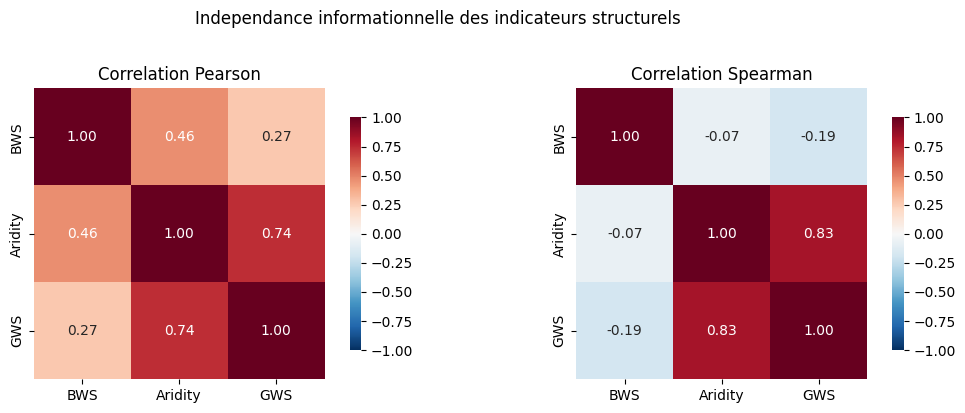

  ATTENTION : sites ecartes (NaN partiel) : {'Brest', 'Rennes'}

--- ACP sur 3 indicateurs, 6 sites ---
  PC1 :  70.3 %  (cumul  70.3%)
  PC2 :  24.4 %  (cumul  94.7%)
  PC3 :   5.3 %  (cumul 100.0%)

  Loadings (composition des composantes principales) :
           PC1    PC2    PC3
BWS      0.503  0.778 -0.376
Aridity  0.656 -0.061  0.752
GWS      0.562 -0.625 -0.541

--- Variance Inflation Factor (VIF) ---
  (VIF > 5 = forte multicollinearite, > 10 = critique)
  BWS        : VIF = 1.84
  Aridity    : VIF = 3.80
  GWS        : VIF = 2.54

--- Verdict ---
  Correlation max (hors diag.) : 0.742  entre Aridity et GWS
  -> Correlation forte, redondance possible a documenter.


In [10]:
"""
Bloc 1 - Analyse multivariee des indicateurs structurels
=========================================================
Objectif : verifier l'independance informationnelle des 4 indicateurs
  (BWS, Aridite, GWS, SV) avant l'agregation.

Methode : matrice de correlation + ACP + Variance Inflation Factor.
Reference : OECD/JRC (Nardo et al. 2005), etape 4.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# 1. Construire la matrice [sites x indicateurs]
indicateurs = []
for name, (lat, lon) in SITES.items():
    bws_raw = extract_raster_point(AQUEDUCT_BWS, lat, lon)
    gws_raw = extract_raster_point(AQUEDUCT_GWS, lat, lon)
    sv_raw  = extract_raster_point(AQUEDUCT_SV, lat, lon) if AQUEDUCT_SV.exists() else np.nan

    x_bws = np.clip(bws_raw / BWS_MAX_FR, 0, 1) if not np.isnan(bws_raw) else np.nan
    x_gws = np.clip(gws_raw / GWS_MAX_FR, 0, 1) if not np.isnan(gws_raw) else np.nan
    x_sv  = np.clip(sv_raw  / SV_MAX_FR,  0, 1) if not np.isnan(sv_raw)  else np.nan

    ds = xr.open_dataset(ERA5_FULL)
    pet_lat, pet_lon = find_land_gridpoint(lat, lon, ds)
    tp = ds['tp'].sel(latitude=lat, longitude=lon, method='nearest')
    t = pd.DatetimeIndex(tp[(td := 'valid_time' if 'valid_time' in ds.dims else 'time')].values)
    dy = t.days_in_month.values.astype(float)
    P = np.maximum(tp.values * dy * 1000, 0)
    pv = ds['pev'].sel(latitude=pet_lat, longitude=pet_lon, method='nearest')
    PET = np.maximum(-pv.values * dy * 1000, 0)
    x_a = compute_aridity(P, PET, t)
    ds.close()

    indicateurs.append({"Site": name, "BWS": x_bws, "Aridity": x_a,
                        "GWS": x_gws, "SV": x_sv})

df_ind = pd.DataFrame(indicateurs).set_index("Site").dropna(axis=1, how="all")
print("=" * 60)
print("Matrice des indicateurs structurels (8 sites)")
print("=" * 60)
print(df_ind.round(3))

# 2. Matrice de correlation Pearson + Spearman
print("\n--- Correlations Pearson ---")
print(df_ind.corr(method="pearson").round(3))
print("\n--- Correlations Spearman (rangs) ---")
print(df_ind.corr(method="spearman").round(3))

# 3. Visualisation heatmap
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, method in zip(axes, ["pearson", "spearman"]):
    sns.heatmap(df_ind.corr(method=method), annot=True, fmt=".2f",
                cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                square=True, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"Correlation {method.capitalize()}")
plt.suptitle("Independance informationnelle des indicateurs structurels",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("fig_correlation_indicateurs.png", dpi=200, bbox_inches="tight")
plt.show()

# Patch : remplacer la section "4. ACP" et "5. VIF" du Bloc 1 par ceci

# 4. Analyse en Composantes Principales (avec gestion NaN)
df_clean = df_ind.dropna(axis=1, how="all")  # drop colonnes 100% NaN
df_clean = df_clean.dropna(axis=0, how="any") # drop lignes avec au moins 1 NaN

dropped_cols = set(df_ind.columns) - set(df_clean.columns)
dropped_rows = set(df_ind.index)   - set(df_clean.index)
if dropped_cols:
    print(f"\n  ATTENTION : colonnes ecartees (entierement NaN) : {dropped_cols}")
if dropped_rows:
    print(f"  ATTENTION : sites ecartes (NaN partiel) : {dropped_rows}")

if df_clean.shape[1] < 2:
    print("\n  ACP impossible : moins de 2 indicateurs valides.")
else:
    X = StandardScaler().fit_transform(df_clean.values)
    pca = PCA()
    pca.fit(X)
    var_explained = pca.explained_variance_ratio_

    print(f"\n--- ACP sur {df_clean.shape[1]} indicateurs, {df_clean.shape[0]} sites ---")
    for i, v in enumerate(var_explained):
        print(f"  PC{i+1} : {v*100:5.1f} %  (cumul {np.sum(var_explained[:i+1])*100:5.1f}%)")

    # Loadings (composition des composantes)
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)],
        index=df_clean.columns,
    )
    print("\n  Loadings (composition des composantes principales) :")
    print(loadings.round(3))

    # 5. VIF
    print("\n--- Variance Inflation Factor (VIF) ---")
    print("  (VIF > 5 = forte multicollinearite, > 10 = critique)")
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    for i, col in enumerate(df_clean.columns):
        vif = variance_inflation_factor(X, i)
        flag = "  <-- attention" if vif > 5 else ""
        print(f"  {col:10s} : VIF = {vif:.2f}{flag}")

# 6. Verdict synthetique (sur df_clean)
if df_clean.shape[1] >= 2:
    corr_off = df_clean.corr().abs().where(~np.eye(df_clean.shape[1], dtype=bool))
    max_corr = corr_off.max().max()
    pair_max = corr_off.stack().idxmax()
    print(f"\n--- Verdict ---")
    print(f"  Correlation max (hors diag.) : {max_corr:.3f}  entre {pair_max[0]} et {pair_max[1]}")
    if max_corr < 0.5:
        print("  -> Independance informationnelle VALIDEE.")
    elif max_corr < 0.7:
        print("  -> Correlation moderee, acceptable pour agregation MCDA.")
    else:
        print("  -> Correlation forte, redondance possible a documenter.")

Benchmark : H_local v2.5a vs WSI Pfister vs Propluvia (juillet 2022)
        Site  H_local_v2.5a  WSI_Pfister  Propluvia_2022
Paris-Saclay          0.562        0.087               2
        Lyon          0.584        0.048               4
   Marseille          0.639        0.336               4
  Strasbourg          0.533        0.050               2
       Brest          0.364        0.124               1
      Rennes          0.431        0.144               4
    Bordeaux          0.360        0.030               3
 Montpellier          0.590        0.010               3

--- Spearman vs Propluvia ---
  H_local_v2.5a      : rho = +0.432 (p = 0.285)
  WSI_Pfister        : rho = +0.148 (p = 0.726)


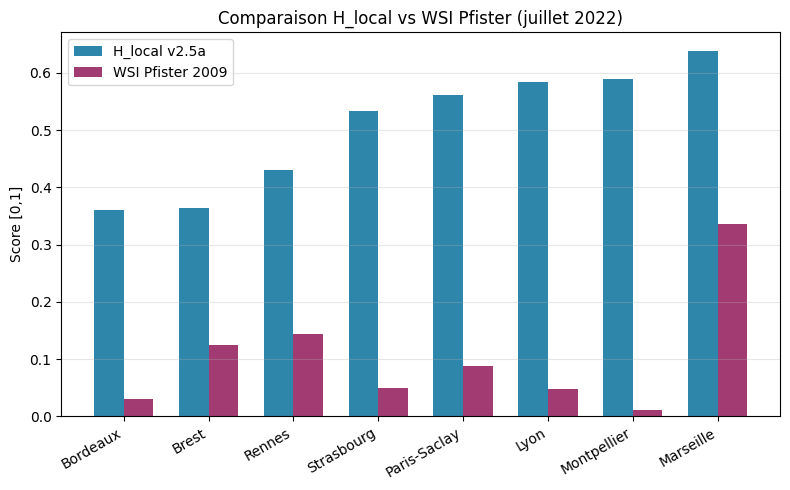

In [11]:
"""
Bloc 2 - Benchmark contre WSI Pfister 2009
==========================================
Reference : Pfister, S., Koehler, A., & Hellweg, S. (2009).
  Assessing the environmental impacts of freshwater consumption in LCA.
  Environmental Science & Technology, 43(11), 4098-4104.

Formule WSI = 1 / (1 + exp(-6.4 * WTA / (1 - WTA)))
  ou WTA = withdrawal-to-availability = BWS_raw / BWS_max
"""

# 1. Calcul WSI Pfister par site
def wsi_pfister(bws_raw, bws_max=5.0):
    """Pfister WSI : logistique modifiee sur BWS."""
    if np.isnan(bws_raw):
        return np.nan
    wta = np.clip(bws_raw / bws_max, 0.001, 0.999)
    raw = 1.0 / (1.0 + np.exp(-6.4 * wta / (1 - wta)))
    return float(np.clip((raw - 0.5) / 0.5, 0, 1))


# 2. Recuperer les H_local v2.5a calcules precedemment + WSI Pfister
benchmark = []
for name, (lat, lon) in SITES.items():
    bws_raw = extract_raster_point(AQUEDUCT_BWS, lat, lon)
    pfister = wsi_pfister(bws_raw)
    # H_v2.5a deja calcule ailleurs (juillet 2022)
    H_v25a = df_v3bis.loc[df_v3bis["Site"] == name, "H_v3bis"].values[0] \
             if name in df_v3bis["Site"].values else np.nan
    benchmark.append({"Site": name, "H_local_v2.5a": H_v25a,
                      "WSI_Pfister": pfister,
                      "Propluvia_2022": PROPLUVIA_2022[name]})

df_bench = pd.DataFrame(benchmark)
print("=" * 70)
print("Benchmark : H_local v2.5a vs WSI Pfister vs Propluvia (juillet 2022)")
print("=" * 70)
print(df_bench.round(3).to_string(index=False))

# 3. Concordance avec Propluvia
print("\n--- Spearman vs Propluvia ---")
for col in ["H_local_v2.5a", "WSI_Pfister"]:
    sub = df_bench.dropna(subset=[col])
    rho, p = stats.spearmanr(sub[col], sub["Propluvia_2022"])
    print(f"  {col:18s} : rho = {rho:+.3f} (p = {p:.3f})")

# 4. Visualisation comparative
fig, ax = plt.subplots(figsize=(8, 5))
sites_order = df_bench.sort_values("H_local_v2.5a")["Site"].tolist()
df_plot = df_bench.set_index("Site").loc[sites_order]
x = np.arange(len(sites_order))
width = 0.35
ax.bar(x - width/2, df_plot["H_local_v2.5a"], width, label="H_local v2.5a", color="#2E86AB")
ax.bar(x + width/2, df_plot["WSI_Pfister"], width, label="WSI Pfister 2009", color="#A23B72")
ax.set_xticks(x); ax.set_xticklabels(sites_order, rotation=30, ha="right")
ax.set_ylabel("Score [0,1]")
ax.set_title("Comparaison H_local vs WSI Pfister (juillet 2022)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_benchmark_pfister.png", dpi=200, bbox_inches="tight")
plt.show()


df_results genere : 24 lignes (8 sites x 3 annees)
        Site  year  S_struct  S_conj  beta_t     H
Paris-Saclay  2015     0.310   0.661   0.237 0.578
Paris-Saclay  2018     0.310   0.512   0.341 0.443
Paris-Saclay  2022     0.310   0.651   0.244 0.568
        Lyon  2015     0.126   0.568   0.302 0.435
        Lyon  2018     0.126   0.227   0.541 0.172
        Lyon  2022     0.126   0.704   0.207 0.584
   Marseille  2015     0.852   0.684   0.221 0.721
   Marseille  2018     0.852   0.000   0.700 0.597
   Marseille  2022     0.852   0.539   0.323 0.640
  Strasbourg  2015     0.226   0.656   0.241 0.552
  Strasbourg  2018     0.226   0.655   0.241 0.551
  Strasbourg  2022     0.226   0.649   0.246 0.545
       Brest  2015     0.245   0.139   0.603 0.203
       Brest  2018     0.245   0.315   0.480 0.281
       Brest  2022     0.245   0.459   0.379 0.378
      Rennes  2015     0.330   0.163   0.586 0.261
      Rennes  2018     0.330   0.000   0.700 0.231
      Rennes  2022     0.330   

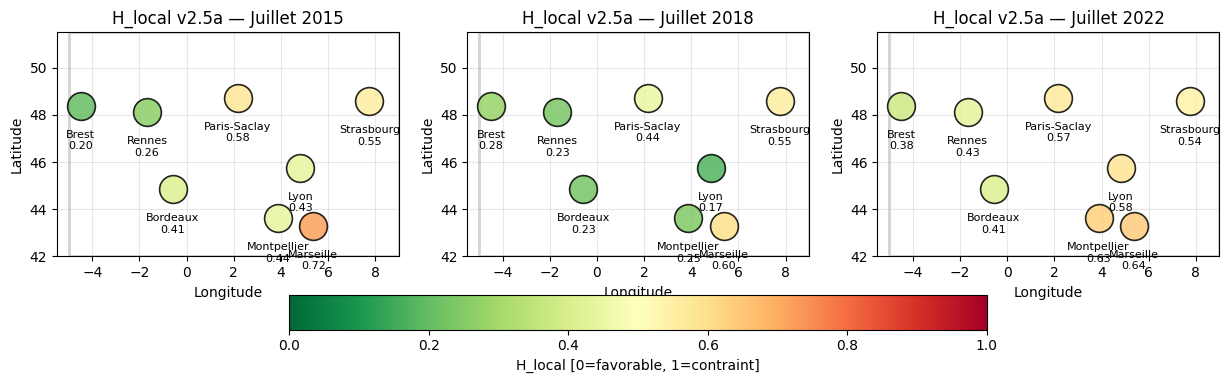

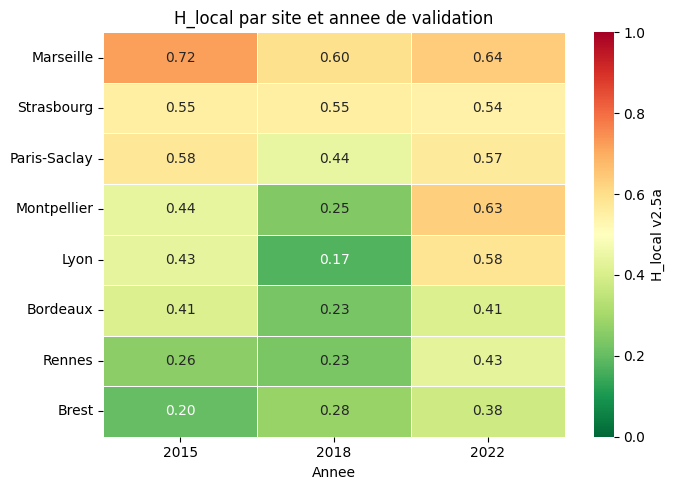

In [13]:
"""
Bloc 3 (corrige) - Visualisations standard
===========================================
Calcule d'abord H_v2.5a (arith + AHP + Boltzmann) pour les 8 sites x 3 annees,
puis genere les 4 figures.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Poids AHP renormalises sur 3 indicateurs (SV non disponible)
W_AHP_3 = {"bws": 0.532/0.902, "aridity": 0.185/0.902, "gws": 0.185/0.902}

def s_struct_arith_ahp(x_bws, x_a, x_gws, weights=W_AHP_3):
    """v2.5a : moyenne arithmetique ponderee AHP, 3 indicateurs."""
    comps = [(weights["bws"], x_bws),
             (weights["aridity"], x_a),
             (weights["gws"], x_gws)]
    valid = [(w, v) for w, v in comps if not np.isnan(v)]
    if not valid:
        return np.nan
    return sum(w*v for w, v in valid) / sum(w for w, _ in valid)

# 1. Calculer df_results pour les 8 sites x 3 annees
rows = []
ds = xr.open_dataset(ERA5_FULL)
td = 'valid_time' if 'valid_time' in ds.dims else 'time'

for name, (lat, lon) in SITES.items():
    bws_raw = extract_raster_point(AQUEDUCT_BWS, lat, lon)
    gws_raw = extract_raster_point(AQUEDUCT_GWS, lat, lon)
    x_bws = np.clip(bws_raw / BWS_MAX_FR, 0, 1) if not np.isnan(bws_raw) else np.nan
    x_gws = np.clip(gws_raw / GWS_MAX_FR, 0, 1) if not np.isnan(gws_raw) else np.nan

    pet_lat, pet_lon = find_land_gridpoint(lat, lon, ds)
    tp = ds['tp'].sel(latitude=lat, longitude=lon, method='nearest')
    t = pd.DatetimeIndex(tp[td].values)
    dy = t.days_in_month.values.astype(float)
    P = np.maximum(tp.values * dy * 1000, 0)
    pv = ds['pev'].sel(latitude=pet_lat, longitude=pet_lon, method='nearest')
    PET = np.maximum(-pv.values * dy * 1000, 0)
    x_a = compute_aridity(P, PET, t)
    spei12 = compute_spei(P, PET, t, 12)
    spei3  = compute_spei(P, PET, t, 3)

    for year, month in VALIDATION_DATES:
        idx = next((i for i, tt in enumerate(t)
                    if tt.year == year and tt.month == month), None)
        if idx is None:
            continue
        d3, d12 = f_asym(spei3[idx]), f_asym(spei12[idx])
        s_struct = s_struct_arith_ahp(x_bws, x_a, x_gws)
        s_conj   = s_conj_boltzmann(d3, d12)
        beta_t   = BETA_0 * (1 - s_conj)
        H        = float(np.clip(beta_t * s_struct + (1 - beta_t) * s_conj, 0, 1))
        rows.append({
            "Site": name, "year": year,
            "x_bws": x_bws, "x_a": x_a, "x_gws": x_gws,
            "S_struct": s_struct, "S_conj": s_conj,
            "beta_t": beta_t, "H": H,
        })

ds.close()
df_results = pd.DataFrame(rows)
print(f"df_results genere : {len(df_results)} lignes "
      f"({df_results['Site'].nunique()} sites x {df_results['year'].nunique()} annees)")
print(df_results[["Site", "year", "S_struct", "S_conj", "beta_t", "H"]].round(3).to_string(index=False))

# ============================================================
# FIGURE 1 : Carte de France
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, year in zip(axes, [2015, 2018, 2022]):
    sub = df_results[df_results["year"] == year].set_index("Site")
    ax.set_xlim(-5.5, 9); ax.set_ylim(42, 51.5)
    ax.set_aspect("equal")
    ax.add_patch(plt.Rectangle((-5, 42), 14, 9.5, fill=False,
                               edgecolor="lightgray", linewidth=2))
    for name, (lat, lon) in SITES.items():
        if name in sub.index:
            H = sub.loc[name, "H"]
            color = plt.cm.RdYlGn_r(H)
            ax.scatter(lon, lat, s=400, c=[color], edgecolors="black",
                       linewidths=1.2, alpha=0.85, zorder=3)
            ax.annotate(f"{name}\n{H:.2f}", (lon, lat),
                        fontsize=8, ha="center", va="center",
                        xytext=(0, -25), textcoords="offset points")
    ax.set_title(f"H_local v2.5a — Juillet {year}", fontsize=12)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.grid(alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r, norm=plt.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation="horizontal", shrink=0.6,
             pad=0.1, label="H_local [0=favorable, 1=contraint]")
plt.savefig("fig_carte_france.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 2 : Heatmap site x annee
# ============================================================
pivot = df_results.pivot(index="Site", columns="year", values="H")
sites_order = pivot.mean(axis=1).sort_values(ascending=False).index
pivot = pivot.loc[sites_order]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r",
            vmin=0, vmax=1, cbar_kws={"label": "H_local v2.5a"},
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("H_local par site et annee de validation")
ax.set_xlabel("Annee"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig("fig_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


In [17]:
"""
Bloc 4 - Sobol et monotonicite SUR LA VERSION FINALE v2.5a
"""

import numpy as np
import pandas as pd
from itertools import product
from SALib.sample import saltelli
from SALib.analyze import sobol


# Poids AHP complets (4 indicateurs) et renormalises (3 indicateurs)
W_AHP   = {"bws": 0.532, "aridity": 0.185, "gws": 0.185, "sv": 0.097}
W_AHP_3 = {"bws": 0.532/0.902, "aridity": 0.185/0.902, "gws": 0.185/0.902}


def H_local_v25a(x_bws, x_a, x_gws, x_sv, spei3, spei12,
                 weights=None, beta_0=0.70):
    """v2.5a : arith + AHP + Boltzmann + beta dynamique."""
    sv_valid = not np.isnan(x_sv) if x_sv is not None else False
    if weights is None:
        weights = W_AHP if sv_valid else W_AHP_3
    if sv_valid:
        comps = [(weights["bws"], x_bws), (weights["aridity"], x_a),
                 (weights["gws"], x_gws), (weights["sv"], x_sv)]
    else:
        comps = [(weights["bws"], x_bws), (weights["aridity"], x_a),
                 (weights["gws"], x_gws)]
    valid = [(w, v) for w, v in comps if not np.isnan(v)]
    s_struct = sum(w*v for w, v in valid) / sum(w for w, _ in valid)
    d3, d12 = f_asym(spei3), f_asym(spei12)
    s_conj = s_conj_boltzmann(d3, d12)
    beta_t = beta_0 * (1 - s_conj)
    return float(np.clip(beta_t * s_struct + (1 - beta_t) * s_conj, 0, 1))


def test_monotonicity_v25a(n_grid=6, delta=0.01):
    grid = np.linspace(0.05, 0.95, n_grid)
    spei_grid = [-3.0, -1.5, 0.0]
    variables = ["x_bws", "x_a", "x_gws", "x_sv"]
    results = {v: {"checks": 0, "violations": 0, "min_grad": np.inf} for v in variables}

    for x_bws, x_a, x_gws, x_sv in product(grid, repeat=4):
        for spei3, spei12 in product(spei_grid, repeat=2):
            H0 = H_local_v25a(x_bws, x_a, x_gws, x_sv, spei3, spei12)
            for var in variables:
                dx = {"x_bws": 0, "x_a": 0, "x_gws": 0, "x_sv": 0}
                dx[var] = delta
                H1 = H_local_v25a(x_bws + dx["x_bws"], x_a + dx["x_a"],
                                  x_gws + dx["x_gws"], x_sv + dx["x_sv"],
                                  spei3, spei12)
                grad = (H1 - H0) / delta
                results[var]["checks"] += 1
                results[var]["min_grad"] = min(results[var]["min_grad"], grad)
                if grad < -1e-9:
                    results[var]["violations"] += 1
    return results


print("=" * 60)
print("v2.5a (FINAL) - Monotonicite formelle")
print("=" * 60)
mono = test_monotonicity_v25a()
for var, res in mono.items():
    status = "PASS" if res["violations"] == 0 else f"FAIL ({res['violations']})"
    print(f"  d H / d {var:8s} >= 0  :  {status:>12s}  (min grad = {res['min_grad']:+.4f})")


# Sobol operationnel multi-site
print("\n" + "=" * 60)
print("v2.5a (FINAL) - Sobol operationnel multi-site")
print("=" * 60)

SITES_TEST = [
    ("Brest",     0.34, 0.02, 0.13, 0.30, -0.512, -0.863),
    ("Lyon",      0.22, 0.16, 0.47, 0.50, -0.842, -1.296),
    ("Marseille", 1.00, 0.80, 0.13, 0.65, -0.654, -0.943),
]
problem = {
    "num_vars": 4,
    "names": ["w_bws", "w_a", "w_gws", "w_sv"],
    "bounds": [[0.45, 0.65], [0.13, 0.25], [0.13, 0.25], [0.05, 0.15]],
}
np.random.seed(42)
param_values = saltelli.sample(problem, 1024, calc_second_order=False)

for site_name, x_bws, x_a, x_gws, x_sv, spei3, spei12 in SITES_TEST:
    Y = np.zeros(param_values.shape[0])
    for i, params in enumerate(param_values):
        w_bws, w_a, w_gws, w_sv = params
        s = w_bws + w_a + w_gws + w_sv
        weights = {"bws": w_bws/s, "aridity": w_a/s,
                   "gws": w_gws/s, "sv": w_sv/s}
        Y[i] = H_local_v25a(x_bws, x_a, x_gws, x_sv, spei3, spei12, weights=weights)
    Si = sobol.analyze(problem, Y, calc_second_order=False, print_to_console=False)
    df_s = pd.DataFrame({
        "Param": problem["names"],
        "S1": np.round(Si["S1"], 4),
        "ST": np.round(Si["ST"], 4),
        "Inter": np.round(Si["ST"] - Si["S1"], 4),
    }).sort_values("ST", ascending=False)
    print(f"\n--- {site_name} ---")
    print(df_s.to_string(index=False))


v2.5a (FINAL) - Monotonicite formelle
  d H / d x_bws    >= 0  :          PASS  (min grad = +0.1491)
  d H / d x_a      >= 0  :          PASS  (min grad = +0.0519)
  d H / d x_gws    >= 0  :          PASS  (min grad = +0.0519)
  d H / d x_sv     >= 0  :          PASS  (min grad = +0.0272)

v2.5a (FINAL) - Sobol operationnel multi-site

--- Brest ---
Param     S1     ST  Inter
  w_a 0.5244 0.5265 0.0021
w_bws 0.3145 0.3158 0.0013
w_gws 0.1293 0.1305 0.0012
 w_sv 0.0292 0.0299 0.0008

--- Lyon ---
Param     S1     ST  Inter
w_gws 0.3746 0.3764 0.0018
 w_sv 0.3497 0.3521 0.0024
  w_a 0.1584 0.1595 0.0012
w_bws 0.1132 0.1157 0.0025


/var/folders/1s/qxy7g5bd32x92pbdgm67xd0m0000gp/T/ipykernel_13871/244660499.py:85: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024, calc_second_order=False)



--- Marseille ---
Param     S1     ST  Inter
w_gws 0.7176 0.7200 0.0024
w_bws 0.2602 0.2618 0.0016
 w_sv 0.0170 0.0181 0.0011
  w_a 0.0017 0.0029 0.0012
